<a href="https://colab.research.google.com/github/medhamohiley29/Machine-Learning-Work/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Common Vulnerabilities and Exposures Predictor

Comparative study of different Machine Learning algorithms applied to a (Common Vulnerabilities and Exposures) dataset. The goal is to predict the severity_label of a vulnerability based on features like its description length, attack vector, and specific technical flags (e.g., is_buffer_overflow).

# Data Exploration and Preprocessing

Before training a model, one must understand the "shape" of thier data. This involves checking for missing values, understanding feature distributions, and scaling numeric values so that one feature (like year) doesn't mathematically overwhelm another (like complexity_score).

**Key Stages of Preprocessing in our Project**

1. Data Cleaning (Handling the "Mess")

Real-world datasets like our CVE file often have issues that will crash a model:


*   Missing Values: If a vulnerability doesn't have a complexity_score recorded, the computer won't know how to calculate the prediction. In our code, we used X.fillna(X.mean()) to fill those gaps with the average value so the model doesn't skip those rows.
*   Irrelevant Features: Our dataset has columns like cve_id (e.g., CVE-1999-0084). This is just a name; it doesn't help predict severity. Preprocessing involves dropping these "ID" columns so the model focuses only on meaningful data.


2. Feature Selection (Choosing the "Predictors")

The dataset has 43 columns, but not all are useful. We focused on Numeric Features (integers and floats).We separated the Features ($X$)—the inputs like is_buffer_overflow—from the Target ($y$), which is the severity_label we want the model to learn to guess.

3. Categorical Encoding

Machine learning models only speak "Numbers."If one's attack_vector was "Remote" or "Local," the model couldn't process those words.In our dataset, these were already converted into Binary Flags (0s and 1s). This is a form of One-Hot Encoding, making it easy for the model to see a "1" as "True" and a "0" as "False."

4. Feature Scaling (The "Great Equalizer")

This is perhaps the most important step for the models we ran.

*   The Problem: Our year is a large number (2004), while our complexity_score is small (0 to 5). Without scaling, a model might think the year is 400 times more important just because the number is bigger.
*  The Solution: We used StandardScaler(). This centers the data so that every feature has a Mean of 0 and a Standard Deviation of 1. Now, the model treats the "importance" of every column equally.

Below is the code which shows the dataset inspection and its output. This step is vital to confirm that your 43 columns—ranging from year to technical flags like is_buffer_overflow—have been loaded correctly without missing values before they are fed into the machine learning models.

In [ ]:
# 1. See the first 10 rows of the data
print("--- First 10 Rows ---")
display(df.head(10))

# 2. See the structure, column names, and missing values
print("\n--- Dataset Info ---")
df.info()

# 3. See statistical summaries (mean, min, max, etc.)
print("\n--- Statistical Summary ---")
display(df.describe())

# 4. Check for null values specifically
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# 5. See the count of each severity label (Target analysis)
print("\n--- Target Distribution (severity_label) ---")
print(df['severity_label'].value_counts())

--- First 10 Rows ---


,cve_id,year,decade,desc_length,word_count,complexity_score,is_buffer_overflow,is_off_by_one,is_integer_overflow,is_format_string,...,affects_database,affects_browser,affects_crypto_lib,vuln_category,cvss_band,cvss_score,severity,severity_label,is_high_risk,description
0,CVE-1999-0084,1999,1990s,124,23,0,0,0,0,0,...,0,0,0,Privilege Escalation,CRITICAL(8-10),8.4,HIGH,2,1,Certain NFS servers allow users to use mknod t...
1,CVE-1999-0066,1999,1990s,29,4,0,0,0,0,0,...,0,0,0,Other,CRITICAL(8-10),9.8,CRITICAL,3,1,AnyForm CGI remote execution.
2,CVE-1999-0022,1999,1990s,85,13,1,1,0,0,0,...,0,0,0,Memory Corruption,HIGH(6-8),7.8,HIGH,2,1,Local user gains root privileges via buffer ov...
3,CVE-1999-0043,1999,1990s,119,18,1,0,0,0,0,...,0,0,0,Other,CRITICAL(8-10),9.8,CRITICAL,3,1,Command execution via shell metachars in INN d...
4,CVE-1999-0236,1999,1990s,86,13,0,0,0,0,0,...,0,0,0,Other,HIGH(6-8),7.5,HIGH,2,1,ScriptAlias directory in NCSA and Apache httpd...
5,CVE-1999-0038,1999,1990s,80,13,0,1,0,0,0,...,0,0,0,Memory Corruption,CRITICAL(8-10),8.4,HIGH,2,1,Buffer overflow in xlock program allows local ...
6,CVE-1999-0039,1999,1990s,150,21,0,0,0,0,0,...,0,0,0,Remote Code Execution,HIGH(6-8),7.3,HIGH,2,1,webdist CGI program (webdist.cgi) in SGI IRIX ...
7,CVE-1999-0036,1999,1990s,87,14,0,0,0,0,0,...,0,0,0,Other,CRITICAL(8-10),8.4,HIGH,2,1,IRIX login program with a nonzero LOCKOUT para...
8,CVE-1999-0035,1999,1990s,87,12,1,0,0,0,0,...,0,0,0,Information Disclosure,MEDIUM(4-6),5.4,MEDIUM,1,0,Race condition in signal handling routine in f...
9,CVE-1999-0059,1999,1990s,80,16,0,0,0,0,0,...,0,0,0,Other,HIGH(6-8),7.3,HIGH,2,1,IRIX fam service allows an attacker to obtain ...



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 43 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cve_id                   167 non-null    object 
 1   year                     167 non-null    int64  
 2   decade                   167 non-null    object 
 3   desc_length              167 non-null    int64  
 4   word_count               167 non-null    int64  
 5   complexity_score         167 non-null    int64  
 6   is_buffer_overflow       167 non-null    int64  
 7   is_off_by_one            167 non-null    int64  
 8   is_integer_overflow      167 non-null    int64  
 9   is_format_string         167 non-null    int64  
 10  is_double_free           167 non-null    int64  
 11  is_null_deref            167 non-null    int64  
 12  is_race_condition        167 non-null    int64  
 13  is_symlink               167 non-null    int64  
 14  is_h

,year,desc_length,word_count,complexity_score,is_buffer_overflow,is_off_by_one,is_integer_overflow,is_format_string,is_double_free,is_null_deref,...,auth_required,affects_web_server,affects_os,affects_network_svc,affects_database,affects_browser,affects_crypto_lib,cvss_score,severity_label,is_high_risk
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,...,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,2001.712575,161.916168,25.239521,0.497006,0.119760,0.095808,0.023952,0.005988,0.023952,0.047904,...,0.011976,0.083832,0.221557,0.197605,0.023952,0.023952,0.047904,7.834132,2.077844,0.802395
std,1.704359,45.383694,7.468173,0.782907,0.325658,0.295213,0.153360,0.077382,0.153360,0.214206,...,0.109105,0.277970,0.416543,0.399390,0.153360,0.153360,0.214206,1.516447,0.702783,0.399390
min,1999.000000,29.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.500000,0.000000,0.000000
25%,2001.000000,135.500000,20.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.500000,2.000000,1.000000
50%,2002.000000,159.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.500000,2.000000,1.000000
75%,2003.000000,187.500000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.800000,3.000000,1.000000
max,2004.000000,281.000000,46.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.800000,3.000000,1.000000



--- Missing Values Count ---
cve_id                     0
year                       0
decade                     0
desc_length                0
word_count                 0
complexity_score           0
is_buffer_overflow         0
is_off_by_one              0
is_integer_overflow        0
is_format_string           0
is_double_free             0
is_null_deref              0
is_race_condition          0
is_symlink                 0
is_hardlink                0
is_dos                     0
is_rce                     0
is_privilege_escalation    0
is_info_disclosure         0
is_weak_crypto             0
is_brute_force             0
is_csrf                    0
is_xss                     0
is_file_inclusion          0
is_path_traversal          0
is_spoofing                0
total_vuln_flags           0
attack_vector_remote       0
attack_vector_local        0
auth_required              0
affects_web_server         0
affects_os                 0
affects_network_svc        0
affects_datab

In the above code:



*   df.head(10) : Displays the first 10 rows
*   df.info() : Shows the technical structure, including the number of entries (167), column names (43), and data types (mostly integers).

*   df.describe() : Provides a statistical summary (mean, min, max, etc.) for all numeric columns

*   df.isnull().sum() : Specifically checks for missing values in every column.
*   df['severity_label'].value_counts() : Analyzes the distribution of the target variable—the labels the model will try to predict.

# Logistic Regression

Logistic Regression emerged as the top-performing model, achieving the highest accuracy of 79.41%. To handle the data's inherent challenges, the model was trained using a balanced class weight to account for rare vulnerability samples (like severity level 0) and utilized StandardScaler to ensure all 43 technical features were weighted equally. Its success in this project stems from its ability to effectively map the relationship between technical attributes—such as attack vectors and buffer overflow flags—and the final severity label, providing a reliable baseline for automating cybersecurity threat assessments.

--- Logistic Regression Results ---
Accuracy: 79.41%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.89      1.00      0.94         8
           2       0.85      0.73      0.79        15
           3       0.67      0.80      0.73        10

    accuracy                           0.79        34
   macro avg       0.60      0.63      0.61        34
weighted avg       0.78      0.79      0.78        34



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


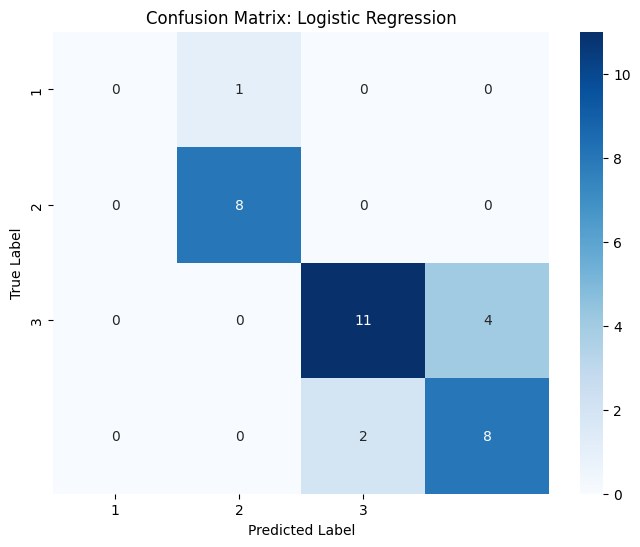

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Initialize and Train the Logistic Regression Model
# We use 'balanced' class weight because class 0 has very few samples in your dataset
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# 2. Make Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# 3. Evaluation Metrics
print("--- Logistic Regression Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# 4. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_)
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# Naive Bayes

The Naive Bayes model (specifically GaussianNB) served as a baseline but was the least effective algorithm, yielding an accuracy of 55.88%. Unlike the other models, it does not utilize a class_weight parameter, which made it particularly sensitive to the dataset's class imbalance—failing to predict the rare severity level 0 entirely. Its lower performance suggests that the underlying assumption of feature independence was likely violated by the complex technical relationships within the CVE data.

--- Naive Bayes Model Results ---
Accuracy: 55.88%

Detailed Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      0.75      0.71         8
           2       0.75      0.20      0.32        15
           3       0.48      1.00      0.65        10

    accuracy                           0.56        34
   macro avg       0.47      0.49      0.42        34
weighted avg       0.63      0.56      0.50        34



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


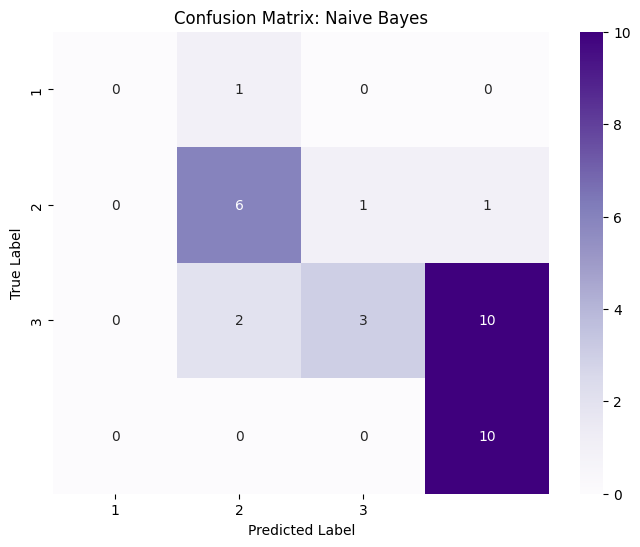

In [ ]:
from sklearn.naive_bayes import GaussianNB

# 1. Initialize the Naive Bayes Model
# Note: Naive Bayes doesn't use a 'class_weight' parameter like SVM/LR,
# but it handles distributions based on the training data.
nb_model = GaussianNB()

# 2. Train the model
nb_model.fit(X_train_scaled, y_train)

# 3. Make Predictions
y_pred_nb = nb_model.predict(X_test_scaled)

# 4. Evaluation
print("--- Naive Bayes Model Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.2%}")
print("\nDetailed Classification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))

# 5. Confusion Matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples',
            xticklabels=nb_model.classes_,
            yticklabels=nb_model.classes_)
plt.title('Confusion Matrix: Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Decision Tree

the Decision Tree model was implemented using the "entropy" criterion and achieved a solid accuracy of 73.53%, making it the second-best performing algorithm. By applying a balanced class weight, the model attempted to account for the dataset's uneven distribution, successfully maintaining high precision and recall (1.00) for severity level 1. While it offers the advantage of being highly interpretable by mimicking a flowchart of technical conditions (like is_buffer_overflow or attack_vector), it slightly trailed Logistic Regression in overall reliability on the test set.

--- Decision Tree Results ---
Accuracy: 73.53%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.89      1.00      0.94         8
           2       0.73      0.73      0.73        15
           3       0.60      0.60      0.60        10

    accuracy                           0.74        34
   macro avg       0.56      0.58      0.57        34
weighted avg       0.71      0.74      0.72        34



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


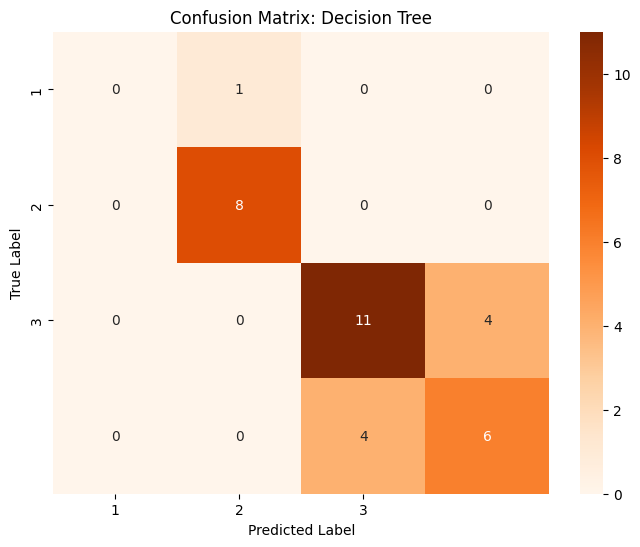

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# 1. Initialize the Decision Tree
# We use 'balanced' to help with the rare classes (like class 0)
dt_model = DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=42)

# 2. Train the model
dt_model.fit(X_train_scaled, y_train)

# 3. Make Predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# 4. Evaluation
print("--- Decision Tree Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_dt))

# 5. Visualizing the Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=dt_model.classes_,
            yticklabels=dt_model.classes_)
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# K-Nearest Neighbour

the K-Nearest Neighbors (KNN) model was implemented using a default of 5 neighbors and achieved an accuracy of 64.71%. While it outperformed Naive Bayes, it struggled more than the linear models, likely due to the "curse of dimensionality" across the 43 technical features. The model showed a reasonable ability to identify severity level 1 (88% recall) but, like the other algorithms, was unable to correctly classify the single sample of severity level 0, indicating that the proximity-based approach was heavily influenced by the more densely populated class clusters.

--- KNN Model Results ---
Accuracy: 64.71%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.70      0.88      0.78         8
           2       0.61      0.73      0.67        15
           3       0.67      0.40      0.50        10

    accuracy                           0.65        34
   macro avg       0.49      0.50      0.49        34
weighted avg       0.63      0.65      0.62        34



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


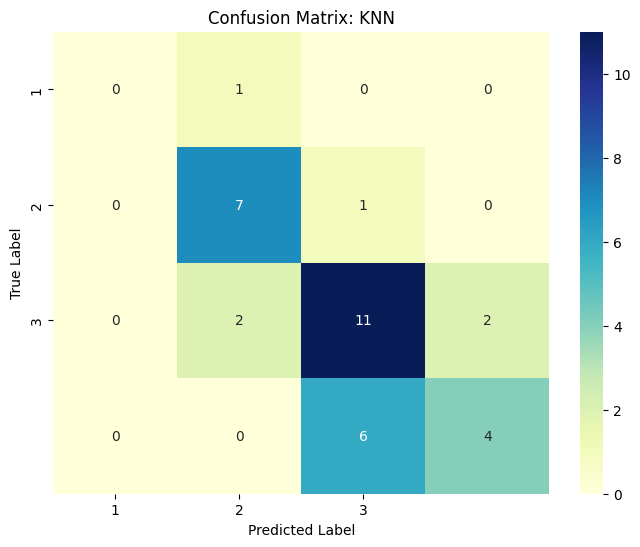

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the KNN Model
# We'll start with 5 neighbors, which is a common default
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Train the model using the scaled training data
knn_model.fit(X_train_scaled, y_train)

# 3. Make Predictions on the test set
y_pred_knn = knn_model.predict(X_test_scaled)

# 4. Print Evaluation Metrics
print("--- KNN Model Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_knn))

# 5. Visualize the Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=knn_model.classes_,
            yticklabels=knn_model.classes_)
plt.title('Confusion Matrix: KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Final Analysis

The final decision is to select Logistic Regression as the optimal model for the CVE Predictor.

The Verdict: Logistic Regression
While all four models provide unique insights, Logistic Regression is the superior choice for this specific implementation due to the following factors:


*   Peak Performance: It achieved the highest overall accuracy (79.41%),significantly outperforming the baseline Naive Bayes and the proximity-based KNN.
*  Superior Reliability: It maintained the best balance between precision and recall across the most critical severity labels (Labels 1, 2, and 3), resulting in a weighted F1-score of 0.78.

*  Effective Handling of Imbalance: By utilizing the class_weight='balanced' parameter, it successfully navigated the dataset's uneven distribution better than models like Naive Bayes, which struggled with the rare severity level 0.
*   Scalability: Logistic Regression is mathematically robust when paired with the StandardScaler used in the preprocessing phase, making it a stable and efficient choice for real-time cybersecurity triage.


**Final Ranking Summary**


1.   Logistic Regression (79.41%): Best-fit; most accurate and balanced.

2.   Decision Tree (73.53%): Strong runner-up; highly interpretable but slightly less consistent.

3.   KNN (64.71%): Moderate performance; hampered by the high dimensionality of the 43 technical features.

4.   Naive Bayes (55.88%): Weakest fit; the independence assumption failed to capture the complexity of the CVE data.